# Inflation Base Effects: Economic Mechanism and Data

## Research question and reading guide

Can a predictable component of annual inflation forecast sovereign bond returns?
The study uses US, German, UK, and Canadian CPI and government-yield proxies.
The primary signal is inherited from the recovered study, not selected from the
new sensitivity results. This is not a preregistered experiment.

Three claims must be kept separate:

1. **Accounting:** a past CPI increase leaves the annual comparison after twelve months.
2. **Expectations:** forecasters revise expectations in response to this predictable component.
3. **Prices:** bond markets underreact, leaving a return opportunity after implementation.

Only the first claim is an identity. Even evidence for the second would not establish
the third. This notebook explains the mechanism and tests US forecast proxies;
[Notebook 2](02_signal_and_backtest.ipynb) tests the portfolio implication, and the
[appendix](03_robustness_and_reconstruction.ipynb) reports diagnostic variations.

All primary calculations use the committed **2026-09-28 current-vintage snapshot**.
There is no network request or credential requirement during notebook execution.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter
from inflation_base_effects.data import REPO_ROOT, compute_base_effect, load_cpi, load_yields
from inflation_base_effects.portfolio import compute_bond_returns
from inflation_base_effects.research import (
    benchmark_regression,
    comparison_table,
    constraint_summary,
    coverage,
    leave_one_out,
    legacy_evaluation_comparison,
    mechanism_regression,
    performance_summary,
    plot_mechanical_effect,
    portfolio_attribution,
    realized_turnover,
    run_experiment,
    sensitivity_experiments,
)

pd.options.display.float_format = "{:.4f}".format
plt.style.use("seaborn-v0_8-whitegrid")
FIGURES = Path(REPO_ROOT) / "docs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

from inflation_base_effects.data import load_michigan, load_spf

## 1. What mechanically happens when an old increase rolls off?

Start with a CPI level of 100. At month **-12**, prices rise once by 1% to 101.
They then stay at 101. Annual inflation is 1% until month **0**, when the comparison
is finally against the already-higher price level. Annual inflation becomes zero,
although prices have not fallen. This is disinflation, not deflation.

The timing bars measure **changes in YoY inflation in percentage points**, not returns,
correlations, or estimated regression coefficients. The second column adds another
proportional 1% increase at month 0 (101 to 102.01): it offsets the departure of the
old increase. Annual inflation need not fall simply because a large old print exits.

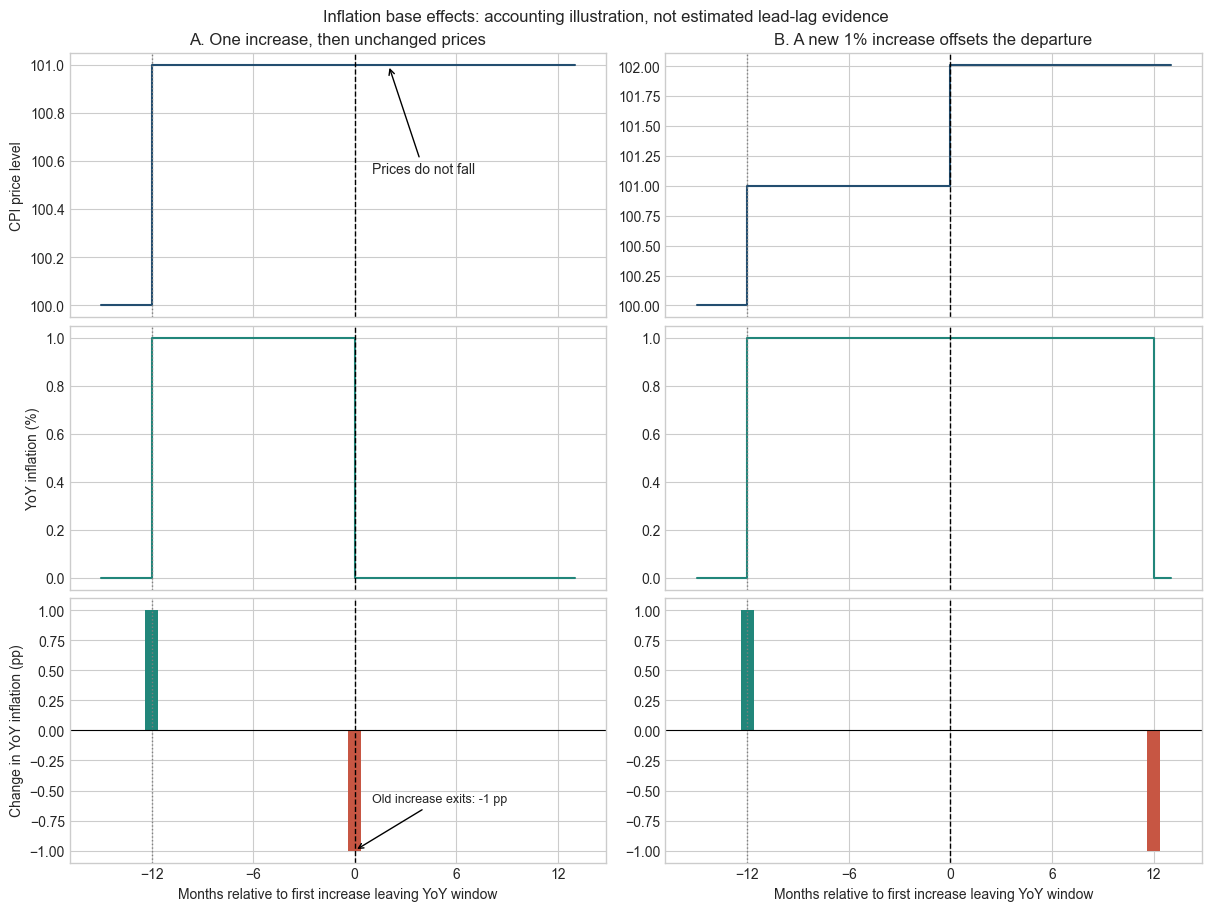

In [2]:
fig, axes = plot_mechanical_effect()
fig.savefig(FIGURES / "mechanical_base_effect.png", dpi=180, bbox_inches="tight")
plt.show()

### Exact log identity versus the ordinary-percentage illustration

Let $p_t=\log(P_t)$ and $m_t=p_t-p_{t-1}$. Twelve-month log inflation is

$$\pi^{YoY}_t=p_t-p_{t-12}=\sum_{j=0}^{11}m_{t-j},\qquad
\Delta\pi^{YoY}_t=m_t-m_{t-12}.$$

The new monthly print enters with a positive sign and the old print leaves with a
negative sign. The code's `rolling_off` is **$m_{t-12}$**, not its negative. A large
positive old print suggests mechanical downward pressure on annual inflation;
the hypothesized trade buys duration. The survey regression instead uses
**$-100m_{t-12}$** so lower predicted inflation and negative forecast revisions
imply a **positive regression coefficient**.

The chart above uses ordinary percentage changes, exactly 1%. Log inflation for
that price increase is $100\log(1.01)$, approximately 0.995%. Do not apply the log
identity as an exact additive identity for ordinary percentage inflation.

## 2. Sources, units, and observation timing

| Input | Source and units | Use and limitation |
|---|---|---|
| NSA CPI levels | FRED / OECD price indices | Monthly log differences; index base does not affect growth |
| 10-year sovereign yields | FRED / OECD, annual percent | Monthly-average synthetic bond-return inputs |
| Michigan expectations | FRED MICH, percent | First difference of next-year inflation expectations; moving target horizon |
| SPF CPI forecasts | Philadelphia Fed, annualized quarterly inflation percent | Same-target quarterly revision; no interpolation |

Series identifiers and retrieval provenance are recorded in the snapshot manifest.
[GS10 documentation](https://fred.stlouisfed.org/series/GS10) explicitly identifies
averages of business days. These are not month-end transaction prices.
[SPF documentation](https://www.philadelphiafed.org/-/media/frbp/assets/surveys-and-data/survey-of-professional-forecasters/spf-documentation.pdf)
records the survey dates and forecast horizons.

Month-start timestamps are **period labels**, not claims that a full month's data
were already available on its first day. The trading experiment separately delays
the signal and uses previous-period holdings.

In [3]:
headline_nsa = load_cpi()
yields_monthly = load_yields()
inf_exp_rev = load_michigan()
spf_rev = load_spf()
bnd_ret_m, duration = compute_bond_returns(yields_monthly)
rolling_off = compute_base_effect(headline_nsa)
display(
    pd.concat(
        {
            "CPI": coverage(headline_nsa),
            "Yield": coverage(yields_monthly),
            "Michigan revision": coverage(inf_exp_rev),
            "SPF revision": coverage(spf_rev),
        },
        names=["dataset", "market"],
    )
)

first                 last    N  \
dataset           market                                                    
CPI               B_EMU_BD  1990-01-01 00:00:00  2023-11-01 00:00:00  407   
                  B_UKI_BD  1990-01-01 00:00:00  2023-11-01 00:00:00  407   
                  B_CAN_BD  1990-01-01 00:00:00  2023-11-01 00:00:00  407   
                  B_USA_BD  1990-01-01 00:00:00  2026-08-01 00:00:00  439   
Yield             B_USA_BD  1990-01-01 00:00:00  2026-08-01 00:00:00  440   
                  B_EMU_BD  1990-01-01 00:00:00  2026-08-01 00:00:00  440   
                  B_UKI_BD  1990-01-01 00:00:00  2026-08-01 00:00:00  440   
                  B_CAN_BD  1990-01-01 00:00:00  2026-08-01 00:00:00  440   
Michigan revision B_USA_BD  1990-02-01 00:00:00  2026-08-01 00:00:00  439   
SPF revision      B_USA_BD  1990-08-01 00:00:00  2026-08-01 00:00:00  146   

                           missing_pct  
dataset           market                
CPI               B_EMU_BD      7.2893  
                  B_UKI_BD      7.2893  
                  B_CAN_BD      7.2893  
                  B_USA_BD      0.0000  
Yield             B_USA_BD      0.0000  
                  B_EMU_BD      0.0000  
                  B_UKI_BD      0.0000  
                  B_CAN_BD      0.0000  
Michigan revision B_USA_BD      0.0000  
SPF revision      B_USA_BD      0.0000

Coverage is part of the research design. Missing observations are not converted
into zero inflation or zero returns. The common-country CPI history ends earlier
than the US history; the last old prints can still generate a rolling-off signal
twelve months later. The one-month implementation delay places the final common
signal in December 2024. The snapshot date does not imply a backtest through 2026.

A frozen snapshot makes the result reproducible today. It does **not** reconstruct
every value originally observed by investors. Publication delays, revisions, and
historical vintages remain separate questions.

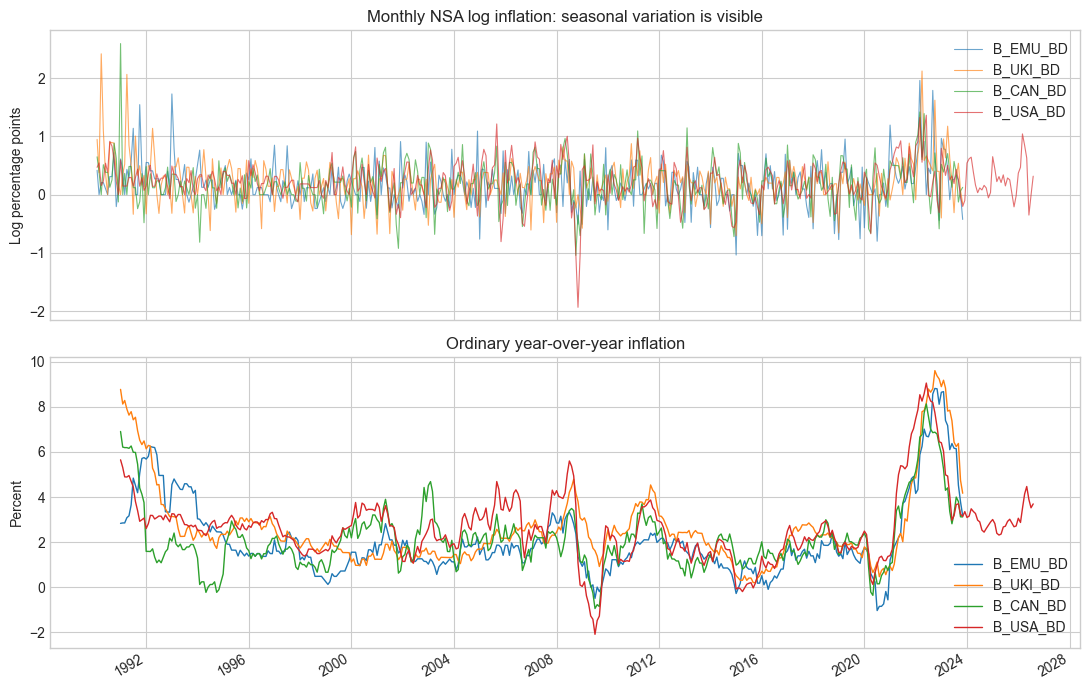

,count,mean,std,min,25%,50%,75%,max
Monthly synthetic return (%),,,,,,,,
B_USA_BD,439.0000,0.4040,1.7761,-5.3802,-0.7506,0.4836,1.5587,9.5784
B_EMU_BD,439.0000,0.3634,1.4744,-7.1268,-0.5559,0.5174,1.3197,4.8392
B_UKI_BD,439.0000,0.4633,1.6938,-10.2162,-0.5448,0.5536,1.5034,5.9743
B_CAN_BD,439.0000,0.4564,1.6482,-4.9476,-0.6837,0.4422,1.5481,5.5219


,missing_return_rows,minimum_duration,maximum_duration
B_USA_BD,0,6.5351,9.6818
B_EMU_BD,0,6.4745,10.3490
B_UKI_BD,0,5.5666,9.8909
B_CAN_BD,0,5.8487,9.7340


In [4]:
monthly_log_pp = 100 * np.log(headline_nsa).diff()
yoy_pct = 100 * (headline_nsa / headline_nsa.shift(12) - 1)
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
monthly_log_pp.plot(ax=axes[0], alpha=0.65, linewidth=0.8)
yoy_pct.plot(ax=axes[1], linewidth=1)
axes[0].set(
    title="Monthly NSA log inflation: seasonal variation is visible", ylabel="Log percentage points"
)
axes[1].set(title="Ordinary year-over-year inflation", ylabel="Percent", xlabel="")
fig.tight_layout()
plt.show()
display((100 * bnd_ret_m).describe().T.rename_axis("Monthly synthetic return (%)"))
display(
    pd.DataFrame(
        {
            "missing_return_rows": bnd_ret_m.isna().sum(),
            "minimum_duration": duration.min(),
            "maximum_duration": duration.max(),
        }
    )
)

The NSA seasonal pattern motivates an **expanding, prior-same-month** normalization
as a robustness check, not a full-sample seasonal decomposition. The latter can use
future observations and is not restored as an investable specification.
Descriptive inflation/return co-movement alone cannot establish predictability.

## 3. Expectations: align the target before taking a difference

Michigan's next-year expectation changes both the forecast and its target horizon
between surveys. Its first difference is therefore an imperfect revision proxy.

For SPF, `CPI3` through `CPI6` refer to forecast quarters $T+1$ through $T+4$.
At survey $T$, `CPI5` forecasts $T+3$; `CPI6` from survey $T-1$ forecasts that
**same calendar quarter**. We use `CPI5_t - CPI6_{t-1}`, not an interpolated monthly
series and not the distinct next-year `INFCP1YR` measure.

The loader maps revisions to official **survey-deadline months**, rather than
assuming that the release month is when respondents formed their forecasts.
The base-effect regressor is already known from an old CPI print. This pairing is
a monthly diagnostic, not a release-day causal event study. Quarterly observations
remain quarterly; we do not manufacture extra observations by forward filling.
Distinct surveys occasionally share a deadline month; each remains a separate
observation paired with that month's known rolling-off print.

In [5]:
display(pd.concat({"Michigan": inf_exp_rev.tail(8), "SPF": spf_rev.tail(8)}, axis=1))

,Michigan,SPF
,B_USA_BD,B_USA_BD
2024-11-01,NaN,-0.0980
2025-02-01,NaN,0.4118
2025-05-01,NaN,0.2856
2025-08-01,NaN,-0.0723
2025-11-01,NaN,0.1000
2026-01-01,-0.2000,NaN
2026-02-01,-0.6000,NaN
2026-03-01,0.4000,-0.1000
2026-04-01,0.9000,NaN


## 4. Mechanism regression and uncertainty

$$\text{revision}_t=a+b(-100m_{t-12})+\epsilon_t.$$

The proposed channel requires $b>0$. Both variables are in percentage-point units.
OLS uses Newey-West HAC standard errors with
$\max(1,\lfloor4(N/100)^{2/9}\rfloor)$ lags at each proxy's native observation
frequency. Report uncertainty, not just signs: a noisy negative estimate is not
evidence that the opposite trading strategy is profitable.

,N,HAC lags,beta,CI lower,CI upper,HAC t,p,R2
Michigan monthly revision,426.0000,5.0000,-0.0736,-0.1869,0.0398,-1.2721,0.2033,0.0050
SPF same-target revision,143.0000,4.0000,-0.0301,-0.1234,0.0633,-0.6316,0.5277,0.0032


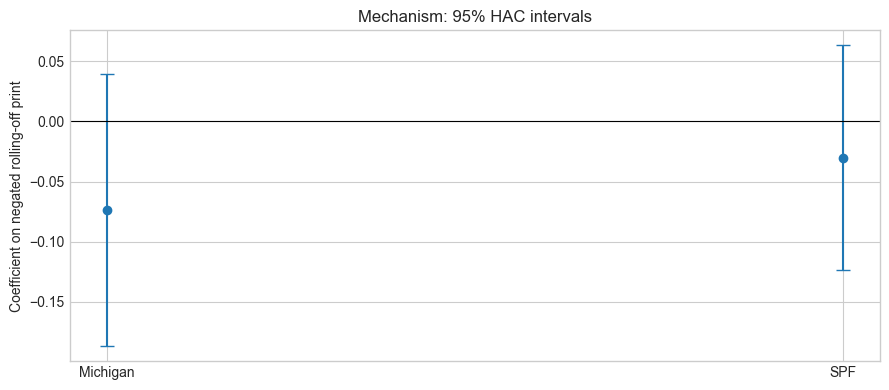

In [6]:
base_effect_pp = -100 * rolling_off["B_USA_BD"]
mechanism_results = pd.DataFrame(
    {
        "Michigan monthly revision": mechanism_regression(base_effect_pp, inf_exp_rev["B_USA_BD"]),
        "SPF same-target revision": mechanism_regression(base_effect_pp, spf_rev["B_USA_BD"]),
    }
).T
display(mechanism_results)
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(mechanism_results))
beta = mechanism_results.beta
ax.errorbar(
    x,
    beta,
    yerr=[beta - mechanism_results["CI lower"], mechanism_results["CI upper"] - beta],
    fmt="o",
    capsize=5,
)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x, ["Michigan", "SPF"])
ax.set(ylabel="Coefficient on negated rolling-off print", title="Mechanism: 95% HAC intervals")
fig.tight_layout()
plt.show()

## 5. Interpretation and boundary of the evidence

Both coefficients have the opposite sign to the proposed expectations channel,
wide intervals, and negligible explanatory power. The public proxies do not
establish this channel. That is not proof of an exactly zero effect.

These are US survey tests: they do not establish how forecasters in Germany,
the UK, or Canada respond. Nor do survey revisions identify the expectations of
the marginal bond investor. Conversely, rejecting or failing to support this
particular proxy channel is not an exhaustive test of every possible mechanism.

The arithmetic illustration establishes only what is mechanically predictable.
The next notebook asks whether the fixed trading interpretation produces positive
performance after realistic information ordering, within the limitations of the
available return proxies.